# International Hotel Review Analytics: Predicting Excellent Guest Satisfaction

## Project overview
This project uses a multi-table hotel review dataset to predict whether a review is **excellent** (`score_overall >= 9.0`) using hotel attributes, user profile information, and review context features.

## Business problem
Hospitality managers want to understand which guest and hotel factors are associated with very positive experiences. A predictive model can help flag patterns linked to excellent reviews and support quality improvement.

## Deliverables covered in this notebook
- Data loading and integration across multiple CSV files
- Data cleaning and feature engineering
- Exploratory data analysis (EDA)
- Predictive modeling with model comparison
- SHAP explainability
- Bias analysis across selected user groups
- Model packaging and scoring script generation

In [49]:
# Import numpy for numerical operations, especially with arrays and mathematical functions.
import numpy as np
# Import pandas for data manipulation and analysis, primarily with DataFrames.
import pandas as pd

# Install shap for model explainability and xgboost for its potential use as a powerful gradient boosting model.
!pip install -q shap xgboost

In [46]:
# Import Path from pathlib for working with file system paths.
from pathlib import Path
# Import warnings for managing warning messages.
import warnings
# Import numpy for numerical operations, especially with arrays and mathematical functions.
import numpy as np
# Import pandas for data manipulation and analysis, primarily with DataFrames.
import pandas as pd
# Import matplotlib.pyplot for creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt
# Import seaborn for creating informative and attractive statistical graphics.
import seaborn as sns
# Import joblib for efficiently saving and loading Python objects, especially large NumPy arrays.
import joblib
# Import shap for model explainability, providing insights into model predictions.
import shap

# Import train_test_split from sklearn.model_selection for splitting data into training and testing sets.
from sklearn.model_selection import train_test_split
# Import ColumnTransformer from sklearn.compose for applying different transformations to different columns.
from sklearn.compose import ColumnTransformer
# Import Pipeline from sklearn.pipeline for chaining multiple processing steps.
from sklearn.pipeline import Pipeline
# Import OneHotEncoder and StandardScaler from sklearn.preprocessing for encoding categorical features and scaling numerical features.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Import SimpleImputer from sklearn.impute for handling missing values.
from sklearn.impute import SimpleImputer
# Import various metrics from sklearn.metrics for evaluating model performance.
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
# Import LogisticRegression from sklearn.linear_model for implementing logistic regression.
from sklearn.linear_model import LogisticRegression
# Import RandomForestClassifier and GradientBoostingClassifier from sklearn.ensemble for ensemble learning models.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Suppress all warnings to prevent cluttering the output.
warnings.filterwarnings("ignore")
# Set pandas option to display all columns in DataFrames.
pd.set_option("display.max_columns", None)
# Set the seaborn visual style to "whitegrid" for plots.
sns.set_theme(style="whitegrid")

# Define Path objects for managing file directories for data, models, and deployment artifacts.
DATA_DIR = Path("/content")
MODELS_DIR = Path("/content/models")
DEPLOYMENT_DIR = Path("/content/deployment")

# Create the models and deployment directories if they do not already exist.
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)

# Print the path to the data directory for verification.
print("Data directory:", DATA_DIR)

Data directory: /content


In [50]:
from google.colab import files
# This line uses google.colab.files.upload() to provide an interactive widget
# that allows users to upload local files (e.g., CSV datasets) directly into
# the Colab runtime environment for use in the notebook.
uploaded = files.upload()

Saving hotels.csv to hotels.csv
Saving reviews.csv to reviews.csv
Saving users.csv to users.csv


In [51]:
import pandas as pd

# Load the 'hotels.csv' file into a pandas DataFrame named 'hotels'.
# DATA_DIR is a Path object indicating the directory where the data files are located.
hotels = pd.read_csv(DATA_DIR / "hotels.csv")

# Load the 'users.csv' file into a pandas DataFrame named 'users'.
users = pd.read_csv(DATA_DIR / "users.csv")

# Load the 'reviews.csv' file into a pandas DataFrame named 'reviews'.
reviews = pd.read_csv(DATA_DIR / "reviews.csv")

# Print the shape (number of rows and columns) of the 'hotels' DataFrame.
print("Hotels shape:", hotels.shape)

# Print the shape of the 'users' DataFrame.
print("Users shape:", users.shape)

# Print the shape of the 'reviews' DataFrame.
print("Reviews shape:", reviews.shape)

Hotels shape: (25, 13)
Users shape: (2000, 6)
Reviews shape: (50000, 12)


In [52]:
# Cell 5:
# Print the column names of the 'hotels' DataFrame to inspect its structure and available features.
print("Hotels columns:")
print(hotels.columns.tolist())

# Print the column names of the 'users' DataFrame to inspect its structure and available features.
print("\nUsers columns:")
print(users.columns.tolist())

# Print the column names of the 'reviews' DataFrame to inspect its structure and available features.
print("\nReviews columns:")
print(reviews.columns.tolist())

Hotels columns:
['hotel_id', 'hotel_name', 'city', 'country', 'star_rating', 'lat', 'lon', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base']

Users columns:
['user_id', 'user_gender', 'country', 'age_group', 'traveller_type', 'join_date']

Reviews columns:
['review_id', 'user_id', 'hotel_id', 'review_date', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'score_staff', 'score_value_for_money', 'review_text']


In [53]:
# Cell 6:
# Merge the 'reviews' DataFrame with the 'users' DataFrame.
# The merge is performed on the 'user_id' column, using a 'left' join to ensure all reviews are kept.
df = reviews.merge(users, on="user_id", how="left")
# Merge the resulting DataFrame 'df' with the 'hotels' DataFrame.
# The merge is performed on the 'hotel_id' column, also using a 'left' join to retain all review-related data.
df = df.merge(hotels, on="hotel_id", how="left")

# Print the shape (number of rows and columns) of the newly merged DataFrame 'df'.
print("Merged shape:", df.shape)
# Display the first few rows of the merged DataFrame to inspect its structure and content.
display(df.head())
# Print a header for the missing values report.
print("\nMissing values after merge:")
# Calculate and display the count of missing values for each column in the merged DataFrame.
# The results are sorted in descending order and the top 20 are shown to highlight columns with significant missing data.
display(df.isnull().sum().sort_values(ascending=False).head(20))

Merged shape: (50000, 29)


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money,review_text,user_gender,country_x,age_group,traveller_type,join_date,hotel_name,city,country_y,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7,Practice reduce young our because machine. Rec...,Female,New Zealand,25-34,Solo,2021-03-21,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6,Test cover traditional black. Process tell Mr ...,Female,United Kingdom,35-44,Couple,2025-04-01,Kyo-to Grand,Tokyo,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6,Friend million student social study yeah. Grow...,Female,Spain,55+,Couple,2021-10-28,Nile Grandeur,Cairo,Egypt,5,30.0444,31.2357,8.8,8.7,8.6,9.1,8.7,8.4
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,8.3,Huge girl already remain truth behind card. Ap...,Female,United Kingdom,35-44,Business,2023-10-10,Gaudi's Retreat,Barcelona,Spain,5,41.3851,2.1734,9.2,9.1,8.9,9.7,9.0,8.8
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,8.9,Cover feeling call community serve television ...,Male,Australia,45-54,Family,2023-02-28,Kremlin Suites,Moscow,Russia,5,55.7558,37.6173,9.1,9.3,9.0,9.0,9.1,8.6



Missing values after merge:


,0
review_id,0
user_id,0
hotel_id,0
review_date,0
score_overall,0
score_cleanliness,0
score_comfort,0
score_facilities,0
score_location,0
score_staff,0


In [54]:
# Cell 7:
# Create a copy of the DataFrame to avoid SettingWithCopyWarning and ensure independent operations.
df = df.copy()

# Convert 'review_date' and 'join_date' columns to datetime objects.
# The errors='coerce' argument will turn invalid date parsing into NaT (Not a Time) values.
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
df["join_date"] = pd.to_datetime(df["join_date"], errors="coerce")

# Create the binary target variable 'excellent_review'.
# It is set to 1 if the 'score_overall' is 9.0 or higher, and 0 otherwise.
df["excellent_review"] = (df["score_overall"] >= 9.0).astype(int)

# Print the value counts of 'excellent_review' to see the distribution of target classes.
print(df["excellent_review"].value_counts())
# Print the normalized value counts to see the proportion of each target class.
print(df["excellent_review"].value_counts(normalize=True))

excellent_review
0    25090
1    24910
Name: count, dtype: int64
excellent_review
0    0.5018
1    0.4982
Name: proportion, dtype: float64


In [55]:
# Cell 8:
# Extract the year from the 'review_date' column and create a new 'review_year' feature.
df["review_year"] = df["review_date"].dt.year
# Extract the month from the 'review_date' column and create a new 'review_month' feature.
df["review_month"] = df["review_date"].dt.month
# Extract the quarter from the 'review_date' column and create a new 'review_quarter' feature.
df["review_quarter"] = df["review_date"].dt.quarter
# Calculate the number of days a user has been a member by subtracting 'join_date' from 'review_date'.
df["membership_days"] = (df["review_date"] - df["join_date"]).dt.days

# Calculate the length of the review text (number of characters).
# .fillna("") handles potential NaN values in 'review_text' by treating them as empty strings.
df["review_text_length"] = df["review_text"].fillna("").str.len()
# Calculate the number of words in the review text.
# .fillna("").str.split() splits the text into words, and .str.len() counts them.
df["review_word_count"] = df["review_text"].fillna("").str.split().str.len()

# Display the first few rows of the DataFrame with the newly engineered features to inspect the changes.
display(df.head())

,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money,review_text,user_gender,country_x,age_group,traveller_type,join_date,hotel_name,city,country_y,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base,excellent_review,review_year,review_month,review_quarter,membership_days,review_text_length,review_word_count
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7,Practice reduce young our because machine. Rec...,Female,New Zealand,25-34,Solo,2021-03-21,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0,0,2022,10,4,565,80,12
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6,Test cover traditional black. Process tell Mr ...,Female,United Kingdom,35-44,Couple,2025-04-01,Kyo-to Grand,Tokyo,Japan,5,35.6895,139.6917,9.6,9.0,9.3,8.5,9.5,8.2,1,2020,3,1,-1834,142,22
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6,Friend million student social study yeah. Grow...,Female,Spain,55+,Couple,2021-10-28,Nile Grandeur,Cairo,Egypt,5,30.0444,31.2357,8.8,8.7,8.6,9.1,8.7,8.4,0,2023,12,4,781,73,11
3,4,1403,19,2022-06-22,8.9,9.0,8.8,8.5,9.6,9.1,8.3,Huge girl already remain truth behind card. Ap...,Female,United Kingdom,35-44,Business,2023-10-10,Gaudi's Retreat,Barcelona,Spain,5,41.3851,2.1734,9.2,9.1,8.9,9.7,9.0,8.8,0,2022,6,2,-475,108,18
4,5,1723,17,2022-07-02,9.1,8.9,9.5,9.3,8.3,9.4,8.9,Cover feeling call community serve television ...,Male,Australia,45-54,Family,2023-02-28,Kremlin Suites,Moscow,Russia,5,55.7558,37.6173,9.1,9.3,9.0,9.0,9.1,8.6,1,2022,7,3,-241,136,17


In [56]:
# Cell 9:
# Define 'leakage_cols': these are columns that directly reveal or are highly correlated with the target variable ('excellent_review')
# and would lead to inflated model performance if included as features.
# They include direct review scores that directly determine if a review is 'excellent'.
leakage_cols = [
    "score_overall",
    "score_cleanliness",
    "score_comfort",
    "score_facilities",
    "score_location",
    "score_staff",
    "score_value_for_money"
]

# Define 'drop_cols': these columns are either identifiers, raw text, or leakage features
# that should not be used directly in model training.
# 'review_id', 'user_id', 'hotel_id' are identifiers.
# 'review_date', 'join_date' are datetimes already used for feature engineering.
# 'excellent_review' is the target variable itself.
# 'review_text' is raw text that would require NLP preprocessing (not covered in this notebook).
# All 'leakage_cols' are also included here to ensure they are removed.
drop_cols = [
    "review_id",
    "user_id",
    "hotel_id",
    "review_date",
    "join_date",
    "excellent_review",
    "review_text"
] + leakage_cols

# Identify 'feature_cols': these are the columns that will be used as input features for the model.
# They are derived by taking all columns from the DataFrame and excluding those in 'drop_cols'.
feature_cols = [c for c in df.columns if c not in drop_cols]

# Identify 'constant_cols': these are columns that have only one unique value (or zero if all are NaN).
# Such columns provide no information for machine learning models and can be removed.
# The 'dropna=False' ensures that NaN values are also considered when counting unique values.
constant_cols = [c for c in feature_cols if df[c].nunique(dropna=False) <= 1]
# Remove constant columns from the 'feature_cols' list.
feature_cols = [c for c in feature_cols if c not in constant_cols]

# Print the list of constant columns that were dropped to inform the user.
print("Dropped constant columns:", constant_cols)
# Print the final list of feature columns that will be used for model training.
print("Feature columns:", feature_cols)

Dropped constant columns: ['star_rating']
Feature columns: ['user_gender', 'country_x', 'age_group', 'traveller_type', 'hotel_name', 'city', 'country_y', 'lat', 'lon', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base', 'review_year', 'review_month', 'review_quarter', 'membership_days', 'review_text_length', 'review_word_count']


In [57]:
# Cell 10:
# Create the feature set X by selecting the identified feature columns from the DataFrame.
X = df[feature_cols].copy()
# Create the target variable y from the 'excellent_review' column.
y = df["excellent_review"].copy()

# Identify numerical features by selecting columns with numeric data types from the feature set X.
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
# Identify categorical features by selecting columns with non-numeric data types from the feature set X.
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Print the identified numeric features.
print("Numeric features:", numeric_features)
# Print the identified categorical features.
print("Categorical features:", categorical_features)
# Print the shape of the feature set X to verify its dimensions.
print("X shape:", X.shape)
# Print the shape of the target variable y to verify its dimensions.
print("y shape:", y.shape)

Numeric features: ['lat', 'lon', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base', 'review_year', 'review_month', 'review_quarter', 'membership_days', 'review_text_length', 'review_word_count']
Categorical features: ['user_gender', 'country_x', 'age_group', 'traveller_type', 'hotel_name', 'city', 'country_y']
X shape: (50000, 21)
y shape: (50000,)


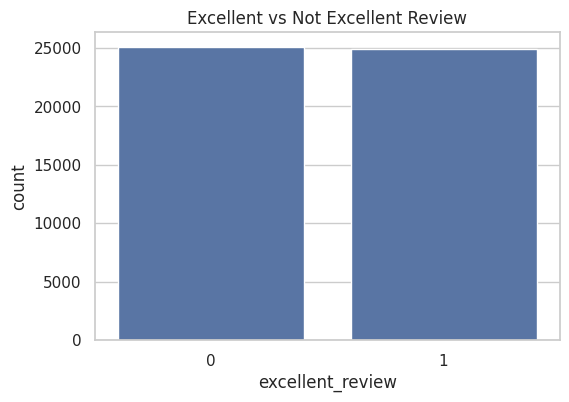

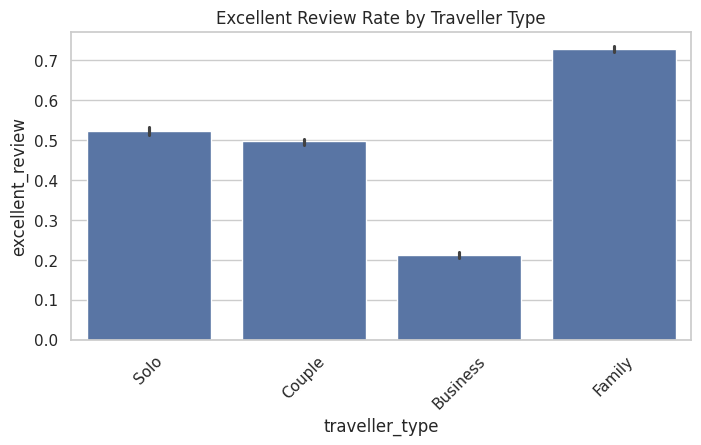

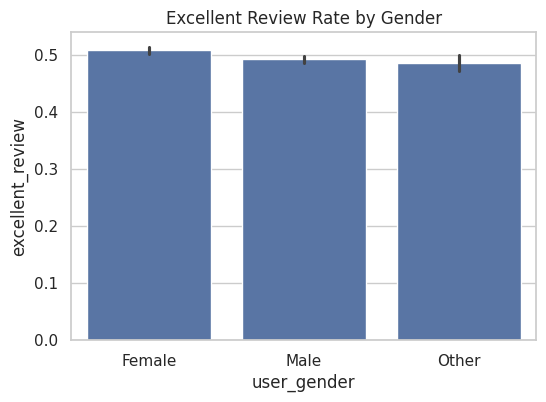

In [59]:
# This cell performs Exploratory Data Analysis (EDA) by visualizing key aspects of the data related to excellent reviews.
#
# - The first plot `sns.countplot(data=df, x="excellent_review")` displays the distribution of 'excellent_review' (our target variable), showing the count of reviews classified as excellent (1) versus not excellent (0). This helps in understanding the class balance.
# - The second plot `sns.barplot(data=df, x="traveller_type", y="excellent_review")` visualizes the excellent review rate across different 'traveller_type' categories. This helps identify if certain traveler types are more likely to give excellent reviews.
# - The third plot `sns.barplot(data=df, x="user_gender", y="excellent_review")` shows the excellent review rate broken down by 'user_gender'. This helps explore potential differences in review patterns based on gender.
#
# These plots provide initial insights into the data and potential relationships between features and the target variable, informing subsequent modeling decisions.
# Cell 11:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="excellent_review")
plt.title("Excellent vs Not Excellent Review")
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=df, x="traveller_type", y="excellent_review")
plt.title("Excellent Review Rate by Traveller Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="user_gender", y="excellent_review")
plt.title("Excellent Review Rate by Gender")
plt.show()

In [ ]:
# Cell 12:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

In [61]:
# Cell 13:
# Initialize OneHotEncoder. handle_unknown='ignore' ensures that if an unseen category is encountered
# during transformation, it will be ignored rather than raising an error. sparse_output=False (or sparse=False for older versions)
# ensures the output is a dense array rather than a sparse matrix.
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Define the pipeline for numerical features.
# It first imputes missing values using the median of the column.
# Then, it scales the numerical features using StandardScaler, which transforms them to have zero mean and unit variance.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Define the pipeline for categorical features.
# It first imputes missing values using the most frequent category in the column.
# Then, it applies one-hot encoding to convert categorical variables into a format suitable for machine learning algorithms.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

# Create a ColumnTransformer to apply different transformers to different columns.
# 'num' applies the numeric_transformer to the identified numeric_features.
# 'cat' applies the categorical_transformer to the identified categorical_features.
# This allows for separate preprocessing of different data types within the same dataset.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [64]:
# Cell 14:
# Define a dictionary of machine learning models to be trained and evaluated.
# Each model is initialized with specific parameters, including `random_state` for reproducibility
# and `n_jobs=-1` for RandomForestClassifier to utilize all available CPU cores.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Initialize an empty list to store the evaluation results for each model.
results = []
# Initialize a dictionary to store the fitted pipelines, allowing access to them later.
fitted_pipelines = {}

# Iterate through each model defined in the 'models' dictionary.
for name, model in models.items():
    # Create a scikit-learn Pipeline for the current model.
    # This pipeline first applies the 'preprocessor' (for numerical and categorical feature transformations)
    # and then feeds the processed data into the 'model' (e.g., Logistic Regression, Random Forest).
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Fit the entire pipeline (preprocessing + model) to the training data.
    # The preprocessor learns parameters (e.g., scaling factors, one-hot categories) from X_train,
    # and the model learns to map processed X_train to y_train.
    pipe.fit(X_train, y_train)
    # Store the fitted pipeline in the dictionary using the model's name.
    fitted_pipelines[name] = pipe

    # Make predictions on the test set using the fitted pipeline.
    # y_pred will contain the predicted class labels (0 or 1).
    y_pred = pipe.predict(X_test)
    # Predict probabilities for the positive class (class 1) on the test set.
    # y_prob will contain the probability of a review being 'excellent'.
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # Calculate various evaluation metrics for the current model's performance on the test set.
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

# Convert the list of results into a pandas DataFrame.
# Sort the DataFrame by 'roc_auc' in descending order to easily identify the best performing model.
# reset_index(drop=True) re-indexes the DataFrame after sorting.
results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
# Display the DataFrame containing the evaluation results for all models.
display(results_df)


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.7750,0.759301,0.802890,0.780488,0.860600
1,Gradient Boosting,0.7740,0.749908,0.819751,0.783276,0.860135
2,Random Forest,0.7649,0.754400,0.783019,0.768443,0.844393


In [65]:
# Cell 15:
# Filter the results_df to include only tree-based models (Random Forest and Gradient Boosting)
# as these are often preferred for their interpretability and performance in many tasks.
# A copy is made to avoid potential SettingWithCopyWarning during subsequent operations.
tree_candidates = results_df[results_df["model"].isin(["Random Forest", "Gradient Boosting"])].copy()

# Determine the final model name by selecting the tree-based model with the highest ROC-AUC score.
# The DataFrame is sorted in descending order by 'roc_auc', and the model name from the first row is chosen.
final_model_name = tree_candidates.sort_values("roc_auc", ascending=False).iloc[0]["model"]

# Retrieve the best-performing model's pipeline from the 'fitted_pipelines' dictionary.
# This pipeline includes both the preprocessing steps and the trained model, ready for further use.
best_pipeline = fitted_pipelines[final_model_name]

# Print the name of the selected final model to inform the user.
# This model will be used for subsequent steps like explainability analysis (SHAP) and deployment.
print("Final model used for explainability and deployment:", final_model_name)

Final model used for explainability and deployment: Gradient Boosting


              precision    recall  f1-score   support

           0       0.80      0.73      0.76      5018
           1       0.75      0.82      0.78      4982

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000



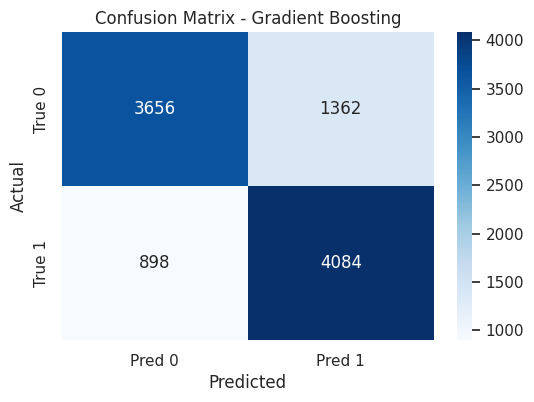

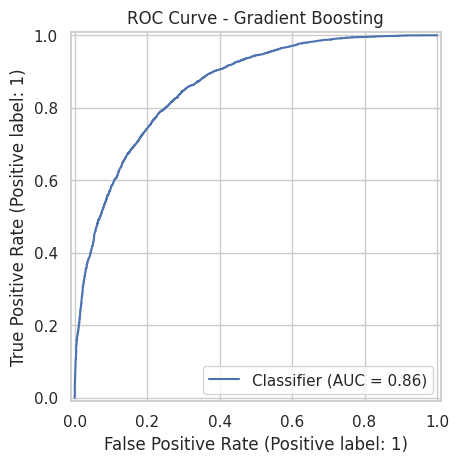

ROC-AUC: 0.8601351273512504


In [66]:
# Cell 16:
# Predict class labels (0 or 1) for the test set using the best_pipeline.
# y_pred will contain the predicted labels for each instance in X_test.
y_pred = best_pipeline.predict(X_test)
# Predict probabilities for the positive class (class 1) on the test set.
# y_prob will contain the probability of each instance belonging to the positive class.
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Print the classification report, which provides a detailed summary of precision, recall, f1-score,
# and support for each class. This helps in understanding the model's performance on different classes.
print(classification_report(y_test, y_pred))

# Calculate the confusion matrix, which shows the counts of true positives, true negatives,
# false positives, and false negatives. It's fundamental for understanding classification errors.
cm = confusion_matrix(y_test, y_pred)
# Create a heatmap visualization of the confusion matrix using seaborn.
# annot=True displays the counts, fmt="d" formats them as integers, and cmap="Blues" sets the color scheme.
# xticklabels and yticklabels provide meaningful labels for the axes.
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
plt.title(f"Confusion Matrix - {final_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the Receiver Operating Characteristic (ROC) curve. This curve illustrates the diagnostic ability
# of a binary classifier system as its discrimination threshold is varied.
# RocCurveDisplay.from_predictions automatically calculates and plots the curve from true labels and predicted probabilities.
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f"ROC Curve - {final_model_name}")
plt.show()

# Calculate and print the Area Under the Receiver Operating Characteristic Curve (ROC-AUC score).
# This is a single scalar metric that summarizes the ROC curve, representing the overall ability
# of the model to distinguish between positive and negative classes.
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

,feature,importance
6,num__staff_base,0.368796
47,cat__traveller_type_Business,0.220482
49,cat__traveller_type_Family,0.109525
3,num__comfort_base,0.089885
2,num__cleanliness_base,0.073246
4,num__facilities_base,0.051093
7,num__value_for_money_base,0.030586
5,num__location_base,0.015815
74,cat__hotel_name_The Royal Compass,0.009679
1,num__lon,0.006366


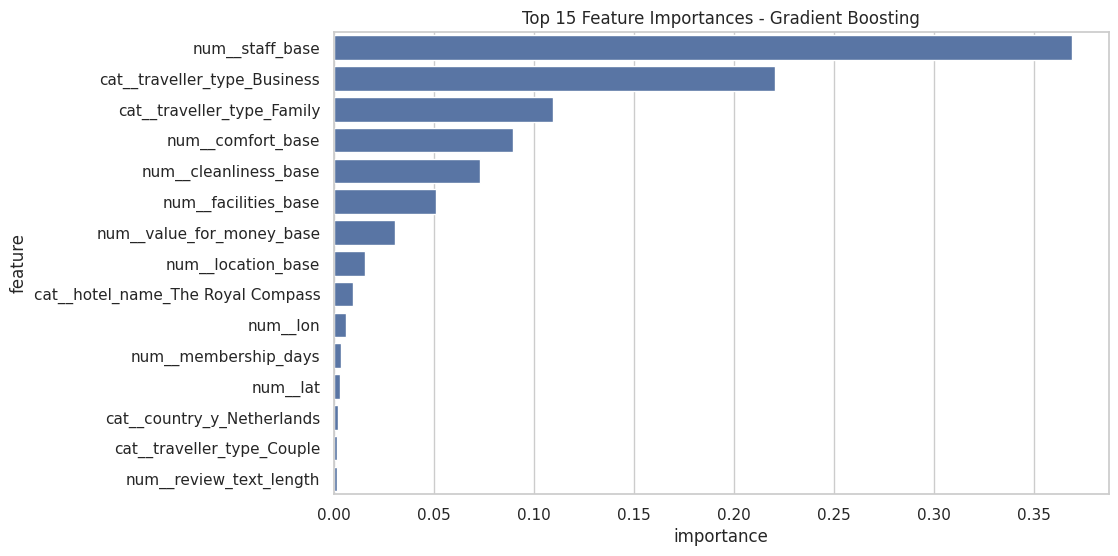

In [67]:
# Cell 17:
# Extract the fitted preprocessor from the best_pipeline. This object contains the learned transformations.
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
# Extract the fitted model (e.g., Gradient Boosting Classifier) from the best_pipeline.
model_fitted = best_pipeline.named_steps["model"]
# Get the names of the features after preprocessing. This is crucial for interpreting feature importances correctly.
feature_names = preprocessor_fitted.get_feature_names_out()

# Create a DataFrame to store feature importances.
# It combines the feature names (from the preprocessor) with the importance scores from the fitted model.
# The DataFrame is then sorted in descending order of importance, and the top 15 features are selected.
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model_fitted.feature_importances_
}).sort_values("importance", ascending=False).head(15)

# Display the DataFrame containing the top 15 feature importances.
display(importance_df)

# Create a bar plot to visualize the top 15 feature importances.
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x="importance", y="feature")
# Set the title of the plot, including the name of the final model.
plt.title(f"Top 15 Feature Importances - {final_model_name}")
# Display the plot.
plt.show()

In [68]:
# Cell 18:
# Sample a subset of the test data (X_test) to speed up SHAP explanation, as SHAP can be computationally intensive.
# min(500, len(X_test)) ensures that we sample at most 500 instances or fewer if X_test is smaller.
# random_state=42 ensures reproducibility of the sampling.
X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

# Transform the sampled test data using the already fitted preprocessor.
# This ensures the input to the SHAP explainer (and the model) is in the same format as during training.
X_sample_transformed = preprocessor_fitted.transform(X_sample)

# Initialize a SHAP TreeExplainer. TreeExplainer is optimized for tree-based models (like RandomForestClassifier and GradientBoostingClassifier).
# It takes the fitted model (model_fitted) to understand its decision-making process.
explainer = shap.TreeExplainer(model_fitted)

# Calculate the SHAP values for the transformed sample data.
# shap_values_raw might be a list for multi-output models (like multi-class classification) or a single array.
shap_values_raw = explainer.shap_values(X_sample_transformed)

# Handle the output format of shap_values_raw.
# If it's a list (e.g., for multi-class, where each element is SHAP values for one class), we typically take the SHAP values for the positive class (index 1).
if isinstance(shap_values_raw, list):
    shap_values_matrix = shap_values_raw[1]
else:
    shap_values_matrix = shap_values_raw

# Further adjust the SHAP values matrix if it's 3-dimensional, which can happen with certain model types or SHAP versions.
# We want a 2D matrix (samples x features) for summary plots.
if len(np.array(shap_values_matrix).shape) == 3:
    shap_values_matrix = shap_values_matrix[:, :, 1]

print("SHAP ready")

SHAP ready


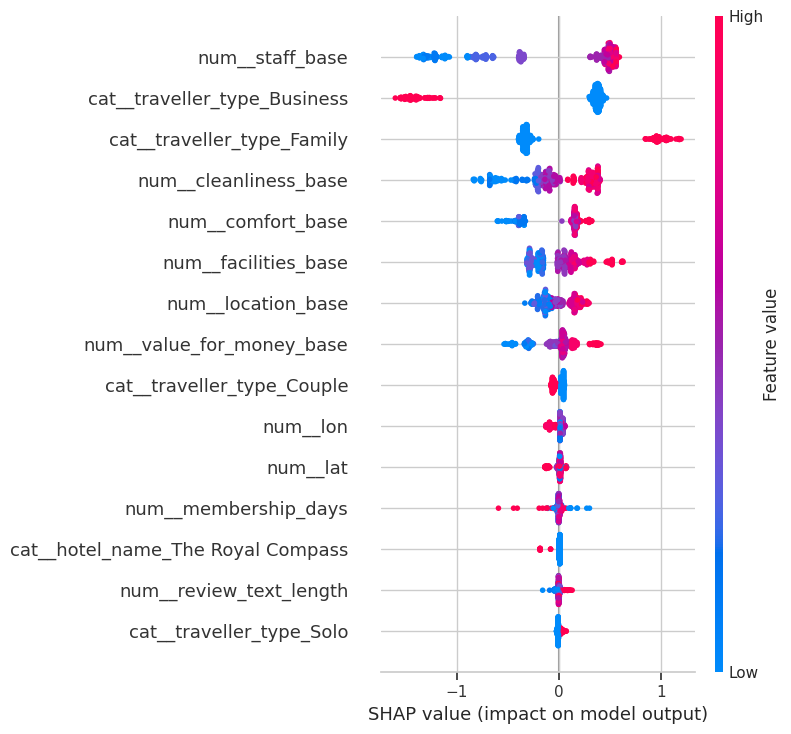

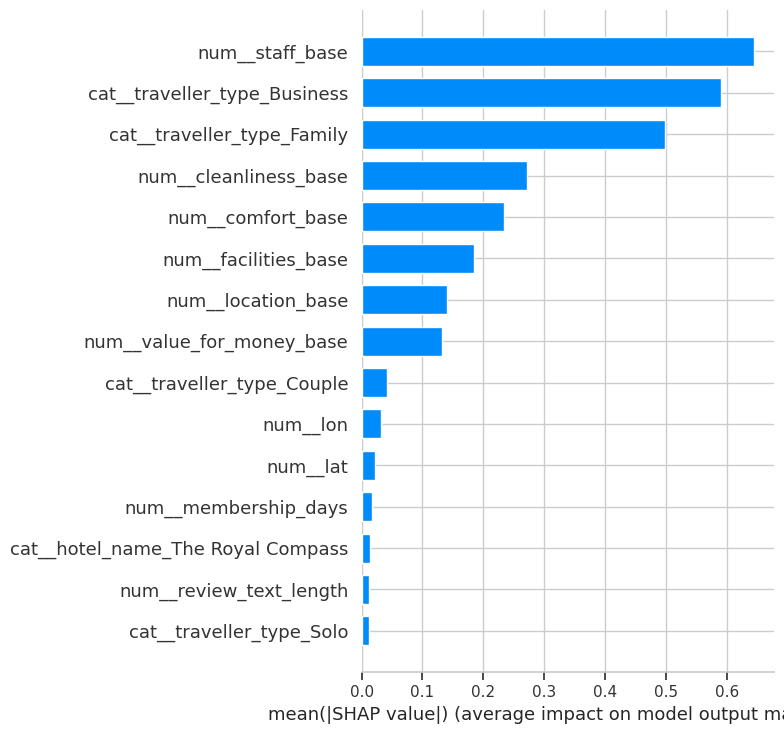

In [73]:
import shap
import matplotlib.pyplot as plt

# Cell 19:
# Generate a SHAP summary plot that shows the distribution of SHAP values for each feature.
# This plot (beeswarm type by default) helps to understand the impact and direction of each feature
# on the model's output for the sampled data.
# 'shap_values_matrix' contains the SHAP values.
# 'X_sample_transformed' provides the underlying data for feature values.
# 'feature_names' labels the features on the y-axis.
# 'max_display=15' limits the plot to the top 15 most important features.
shap.summary_plot(
    shap_values_matrix,
    X_sample_transformed,
    feature_names=feature_names,
    max_display=15
)

# Generate a SHAP bar plot, which is an alternative view of feature importance.
# This plot shows the average absolute SHAP value for each feature, indicating its overall importance
# without direction (magnitude of impact). It's useful for a quick overview of feature relevance.
# 'plot_type="bar"' specifies the type of summary plot.
shap.summary_plot(
    shap_values_matrix,
    X_sample_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15
)

# Ensure plots are displayed
plt.show()

In [70]:
import matplotlib.pyplot as plt

# Cell 20:
# Create a DataFrame 'bias_df' for bias analysis, starting with a copy of the test features.
bias_df = X_test.copy()
# Add the true target labels to the bias_df.
bias_df["y_true"] = y_test.values
# Add the model's predicted labels to the bias_df.
bias_df["y_pred"] = y_pred
# Add the model's predicted probabilities to the bias_df.
bias_df["y_prob"] = y_prob

# Define a function to compute various classification metrics for different subgroups.
# 'data': The DataFrame containing true labels, predicted labels, and group information.
# 'group_col': The name of the column used to define the subgroups (e.g., 'user_gender', 'traveller_type').
# 'min_count': Minimum number of samples required for a group to be included in the analysis, to avoid metrics on very small groups.
def compute_group_metrics(data, group_col, min_count=50):
    rows = []
    # Iterate over each unique group value in the specified group column.
    for group_value, group_data in data.groupby(group_col):
        # Skip groups with fewer samples than 'min_count' to ensure statistical significance.
        if len(group_data) < min_count:
            continue

        # Extract true and predicted labels for the current group.
        yt = group_data["y_true"]
        yp = group_data["y_pred"]
        # Compute the confusion matrix for the current group.
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        # Append a dictionary of computed metrics for the current group.
        rows.append({
            "group": group_value,
            "count": len(group_data),
            "accuracy": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, zero_division=0), # zero_division=0 handles cases where precision might be undefined
            "recall": recall_score(yt, yp, zero_division=0), # zero_division=0 handles cases where recall might be undefined
            "f1": f1_score(yt, yp, zero_division=0),
            "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else 0, # Calculate FPR, handling division by zero
            "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else 0  # Calculate FNR, handling division by zero
        })
    # Convert the list of metric dictionaries into a DataFrame and sort by count.
    return pd.DataFrame(rows).sort_values("count", ascending=False)

# Compute bias metrics for 'user_gender' groups.
gender_metrics = compute_group_metrics(bias_df, "user_gender")
# Compute bias metrics for 'traveller_type' groups.
traveller_metrics = compute_group_metrics(bias_df, "traveller_type")

# Print a header and display the bias metrics for gender.
print("Bias by gender")
display(gender_metrics)

# Print a header and display the bias metrics for traveller type.
print("Bias by traveller type")
display(traveller_metrics)


Bias by gender


,group,count,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate
1,Male,4722,0.772978,0.746175,0.817361,0.780148,0.270146,0.182639
0,Female,4395,0.774061,0.756458,0.822193,0.787956,0.276151,0.177807
2,Other,883,0.779162,0.735808,0.819951,0.775604,0.256356,0.180049


Bias by traveller type


,group,count,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate
1,Couple,3464,0.754908,0.713379,0.847940,0.774861,0.337163,0.152060
2,Family,2379,0.802858,0.821374,0.931871,0.873140,0.542504,0.068129
3,Solo,2089,0.756821,0.729084,0.844875,0.782720,0.337972,0.155125
0,Business,2068,0.790135,0.528090,0.211712,0.302251,0.051724,0.788288


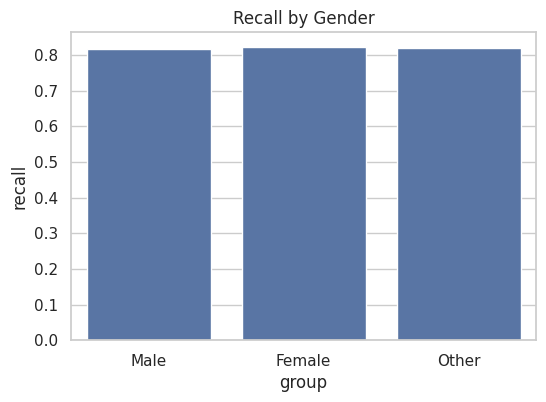

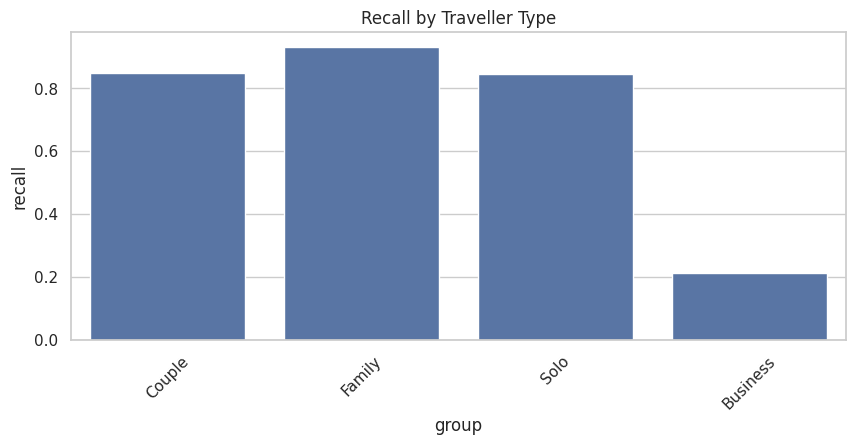

In [71]:
import matplotlib.pyplot as plt

# Cell 21:
# Create a bar plot to visualize the 'recall' metric across different gender groups.
# 'gender_metrics' DataFrame contains the calculated recall for each gender.
# This plot helps to identify potential disparities in model performance (specifically, the ability to correctly identify positive cases) across genders.
plt.figure(figsize=(6,4))
sns.barplot(data=gender_metrics, x="group", y="recall")
plt.title("Recall by Gender")
plt.show()

# Create a bar plot to visualize the 'recall' metric across different traveller types.
# 'traveller_metrics' DataFrame contains the calculated recall for each traveller type.
# This plot helps to identify if the model's ability to identify excellent reviews varies significantly based on the user's traveller type.
plt.figure(figsize=(10,4))
sns.barplot(data=traveller_metrics, x="group", y="recall")
plt.title("Recall by Traveller Type")
plt.xticks(rotation=45)
plt.show()

In [72]:
import joblib

# Cell 22:
# Save the best-performing machine learning pipeline to a joblib file.
# This allows the trained model to be reloaded later for inference without retraining.
joblib.dump(best_pipeline, MODELS_DIR / "best_model.joblib")

# Save the list of feature columns used for training the model.
# This is crucial for ensuring that new data is preprocessed with the same features in the correct order.
joblib.dump(feature_cols, MODELS_DIR / "model_features.joblib")

# Print a confirmation message indicating where the model files have been saved.
print("Saved model files to:", MODELS_DIR)

Saved model files to: /content/models


In [ ]:
# Cell 23:
sample_input = X_test.head(5).copy()
sample_output = sample_input.copy()
sample_output["predicted_label"] = best_pipeline.predict(sample_input)
sample_output["predicted_probability"] = best_pipeline.predict_proba(sample_input)[:, 1]

display(sample_output)

sample_input.to_csv(MODELS_DIR / "sample_scoring_input.csv", index=False)
print("Saved sample_scoring_input.csv")

In [74]:
# Cell 24:
# Define the content of the scoring script as a multi-line string. This script will be saved as 'score.py'
# and is designed for deployment, allowing the trained model to be used for making predictions on new data.
score_script = '''
# Import necessary libraries for the scoring script.
from pathlib import Path # For handling file paths in a cross-platform way.
import argparse # For parsing command-line arguments (e.g., input/output file paths).
import pandas as pd # For data manipulation, especially reading and writing CSVs.
import joblib # For loading the pre-trained machine learning model.

# Define the base directory for the script. It resolves the current script's path
# and then navigates up two levels to find the project's root directory,
# assuming 'models' is a sibling directory to 'deployment'.
BASE_DIR = Path(__file__).resolve().parents[1]
# Define the default path to the saved model file within the 'models' directory.
DEFAULT_MODEL_PATH = BASE_DIR / "models" / "best_model.joblib"

def main():
    # Set up the argument parser to handle command-line inputs.
    parser = argparse.ArgumentParser()
    # Argument for the input CSV file containing features for prediction.
    parser.add_argument("--input", required=True, help="Path to input CSV file")
    # Argument for the output CSV file where predictions will be saved.
    parser.add_argument("--output", default="predictions.csv", help="Path to output CSV file")
    # Argument for the model file path, with a default pointing to the saved model.
    parser.add_argument("--model", default=str(DEFAULT_MODEL_PATH), help="Path to saved model")
    args = parser.parse_args()

    # Load the trained machine learning model using joblib.
    model = joblib.load(args.model)
    # Read the input data from the specified CSV file into a pandas DataFrame.
    input_df = pd.read_csv(args.input)

    # Create a copy of the input DataFrame to store predictions.
    output_df = input_df.copy()
    # Make predictions (class labels) using the loaded model.
    output_df["predicted_label"] = model.predict(input_df)
    # Predict probabilities for the positive class using the loaded model.
    output_df["predicted_probability"] = model.predict_proba(input_df)[:, 1]

    # Save the DataFrame with predictions to the specified output CSV file.
    output_df.to_csv(args.output, index=False)
    print(f"Predictions saved to: {args.output}")

# Ensure that the main function is called only when the script is executed directly.
if __name__ == "__main__":
    main()
'''

# Write the defined 'score_script' string content into a file named 'score.py'
# in the 'DEPLOYMENT_DIR' for later deployment or local testing.
with open(DEPLOYMENT_DIR / "score.py", "w", encoding="utf-8") as f:
    f.write(score_script)

# Print a confirmation message indicating where the scoring script has been saved.
print("score.py written to:", DEPLOYMENT_DIR)


score.py written to: /content/deployment


In [79]:
# Cell 25:
from google.colab import files

# Download the trained machine learning pipeline, which includes preprocessing steps and the model.
files.download(str(MODELS_DIR / "best_model.joblib"))
# Download the list of feature columns used during model training, ensuring consistent input for inference.
files.download(str(MODELS_DIR / "model_features.joblib"))
# Download a sample input CSV file to demonstrate the expected format for new data when making predictions.
files.download(str(MODELS_DIR / "sample_scoring_input.csv"))
# Download the Python script ('score.py') that facilitates model deployment and making predictions on new data.
files.download(str(DEPLOYMENT_DIR / "score.py"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
# Cell 26:
# Create a copy of the main DataFrame 'df' to be used for dashboard purposes.
# This ensures that any subsequent operations on 'dashboard_df' do not affect the original 'df'.
dashboard_df = df.copy()
# Save the 'dashboard_df' to a CSV file. This file can then be used externally
# for building interactive dashboards and visualizations of the analyzed data.
dashboard_df.to_csv("/content/dashboard_dataset.csv", index=False)

from google.colab import files
# Initiate the download of the 'dashboard_dataset.csv' file to the user's local machine.
# This makes the prepared data easily accessible for external tools like Tableau, Power BI, or other dashboarding applications.
files.download("/content/dashboard_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
# Cell 27:
# This cell prepares several datasets for dashboard visualization and further analysis,
# including a comprehensive dashboard dataset, SHAP feature importances, and bias analysis metrics.

# Create a copy of the main DataFrame 'df' to serve as the primary dataset for dashboarding.
# This ensures the original DataFrame remains unchanged and provides a snapshot of the processed data.
dashboard_df = df.copy()
# Save the dashboard DataFrame to a CSV file. This file can be used by external BI tools
# (e.g., Tableau, Power BI) for interactive visualizations.
dashboard_df.to_csv("/content/dashboard_dataset.csv", index=False)

# Calculate the mean absolute SHAP values for each feature to quantify their overall impact.
# This helps in understanding which features are most important across all predictions.
# The results are then sorted and the top 15 features are selected for a concise overview.
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_matrix).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(15)
# Save the top SHAP features and their mean absolute values to a CSV file.
# This file can be used in dashboards to show key model drivers.
shap_importance.to_csv("/content/shap_top_features.csv", index=False)

# Save the gender bias metrics DataFrame to a CSV file.
# This allows for external analysis and visualization of model performance across different gender groups.
gender_metrics.to_csv("/content/gender_metrics.csv", index=False)

# Save the traveller type bias metrics DataFrame to a CSV file.
# This enables external analysis and visualization of model performance across different traveller types.
traveller_metrics.to_csv("/content/traveller_metrics.csv", index=False)

# Download all generated CSV files to the local machine.
# These files are intended for use with external dashboarding tools or further offline analysis.
from google.colab import files
files.download("/content/dashboard_dataset.csv")
files.download("/content/shap_top_features.csv")
files.download("/content/gender_metrics.csv")
files.download("/content/traveller_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>